**Install Libraries**

In [0]:
%pip install lifelines boto3 pandas numpy matplotlib seaborn pyarrow

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


**Import Libraries**

In [0]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows",    20)
pd.set_option("display.width",       1000)

print("All libraries imported successfully!")
print("Lifelines version:", end=" ")
import lifelines
print(lifelines.__version__)

All libraries imported successfully!
Lifelines version: 0.30.3


**Connect to S3 and Load Data**

In [0]:
# ============================================================
# Load cleaned retail data from S3
# ============================================================

from dotenv import load_dotenv
load_dotenv("/Workspace/Users/hsp498@gmail.com/.env")
# AWS Credentials — used for Excel file reads only
ACCESS_KEY = os.getenv("ACCESS_KEY")
SECRET_KEY  = os.getenv("SECRET_KEY")
BUCKET      = os.getenv("BUCKET")
REGION      = os.getenv("REGION")

s3 = boto3.client(
    's3',
    aws_access_key_id     = ACCESS_KEY,
    aws_secret_access_key = SECRET_KEY,
    region_name           = REGION
)

# Load cleaned retail data
print("Loading cleaned retail data from S3...")
obj          = s3.get_object(Bucket=BUCKET, Key="processed/retail_clean.parquet")
retail_clean = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Ensure datetime format
retail_clean['InvoiceDate'] = pd.to_datetime(retail_clean['InvoiceDate'])

print(f"Rows loaded  : {len(retail_clean):,}")
print(f"Date range   : {retail_clean['InvoiceDate'].min()} → {retail_clean['InvoiceDate'].max()}")
print("Data loaded successfully!")

Loading cleaned retail data from S3...
Rows loaded  : 805,549
Date range   : 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Data loaded successfully!


**Engineer Survival Features**

In [0]:
# ============================================================
# Build Customer-Level Survival Dataset
#
# For survival analysis we need per customer:
# duration  = days from first purchase to last purchase
# churned   = 1 if no purchase in last 90 days, 0 if still active
# covariates = features that explain churn behaviour
# ============================================================

print("Engineering survival features...\n")

# Reference date = last date in dataset
reference_date = retail_clean['InvoiceDate'].max()
print(f"Reference date (last transaction) : {reference_date.date()}")
print(f"Churn definition                  : No purchase in last 90 days\n")

# Aggregate to customer level
customer_stats = retail_clean.groupby('Customer ID').agg(
    first_purchase  = ('InvoiceDate', 'min'),
    last_purchase   = ('InvoiceDate', 'max'),
    total_orders    = ('Invoice',     'nunique'),
    total_spend     = ('TotalSpend',  'sum'),
    total_items     = ('Quantity',    'sum'),
    unique_products = ('StockCode',   'nunique'),
    avg_order_value = ('TotalSpend',  'mean'),
    favourite_country = ('Country',   lambda x: x.mode()[0])
).reset_index()

# Calculate survival columns
customer_stats['duration'] = (
    customer_stats['last_purchase'] - customer_stats['first_purchase']
).dt.days

# A customer has churned if their last purchase
# was more than 90 days before the reference date
customer_stats['days_since_last'] = (
    reference_date - customer_stats['last_purchase']
).dt.days

customer_stats['churned'] = (
    customer_stats['days_since_last'] > 90
).astype(int)

# Purchase frequency = orders per month
customer_stats['tenure_months'] = (
    customer_stats['duration'] / 30
).clip(lower=0.1)  # avoid division by zero

customer_stats['purchase_frequency'] = (
    customer_stats['total_orders'] / customer_stats['tenure_months']
)

# Ensure duration is at least 1 day
customer_stats['duration'] = customer_stats['duration'].clip(lower=1)

print(f"Total customers          : {len(customer_stats):,}")
print(f"Churned customers        : {customer_stats['churned'].sum():,} ({customer_stats['churned'].mean()*100:.1f}%)")
print(f"Active customers         : {(customer_stats['churned']==0).sum():,} ({(customer_stats['churned']==0).mean()*100:.1f}%)")
print(f"\nAverage customer tenure  : {customer_stats['duration'].mean():.0f} days")
print(f"Avg total spend          : £{customer_stats['total_spend'].mean():,.2f}")
print(f"Avg orders per customer  : {customer_stats['total_orders'].mean():.1f}")
print(f"\nSample of survival data:")
print(customer_stats[['Customer ID','duration','churned',
                       'total_orders','total_spend',
                       'avg_order_value','purchase_frequency']].head(8).to_string())

Engineering survival features...

Reference date (last transaction) : 2011-12-09
Churn definition                  : No purchase in last 90 days

Total customers          : 5,878
Churned customers        : 2,985 (50.8%)
Active customers         : 2,893 (49.2%)

Average customer tenure  : 273 days
Avg total spend          : £3,018.62
Avg orders per customer  : 6.3

Sample of survival data:
   Customer ID  duration  churned  total_orders  total_spend  avg_order_value  purchase_frequency
0        12346       400        1            12     77556.46      2281.072353            0.900000
1        12347       402        0             8      5633.32        22.266087            0.597015
2        12348       362        0             5      2019.40        39.596078            0.414365
3        12349       570        0             4      4428.69        25.306800            0.210526
4        12350         1        1             1       334.40        19.670588           10.000000
5        12351      

**Kaplan-Meier Survival Curve (Overall)**

Fitting Kaplan-Meier survival model...



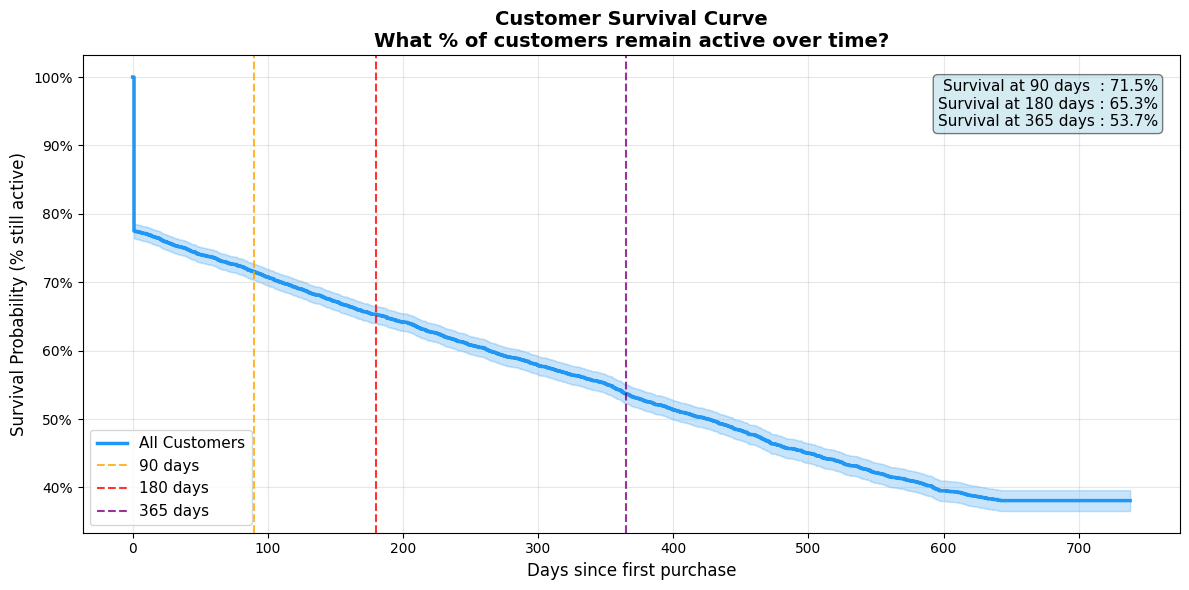

Survival at 90 days  : 71.5%
Survival at 180 days : 65.3%
Survival at 365 days : 53.7%

Median survival time : 425 days


In [0]:
# ============================================================
# Kaplan-Meier Survival Curve — Overall
# Shows: what % of customers are still active over time
# ============================================================

print("Fitting Kaplan-Meier survival model...\n")

kmf = KaplanMeierFitter()
kmf.fit(
    durations       = customer_stats['duration'],
    event_observed  = customer_stats['churned'],
    label           = 'All Customers'
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

kmf.plot_survival_function(
    ax         = ax,
    ci_show    = True,
    color      = '#2196F3',
    linewidth  = 2.5
)

# Add reference lines
ax.axvline(x=90,  color='orange', linestyle='--',
           linewidth=1.5, alpha=0.8, label='90 days')
ax.axvline(x=180, color='red',    linestyle='--',
           linewidth=1.5, alpha=0.8, label='180 days')
ax.axvline(x=365, color='purple', linestyle='--',
           linewidth=1.5, alpha=0.8, label='365 days')

# Survival probabilities at key milestones
prob_90  = kmf.survival_function_at_times([90]).values[0]
prob_180 = kmf.survival_function_at_times([180]).values[0]
prob_365 = kmf.survival_function_at_times([365]).values[0]

ax.set_title(
    'Customer Survival Curve\nWhat % of customers remain active over time?',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Days since first purchase', fontsize=12)
ax.set_ylabel('Survival Probability (% still active)', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%')
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotation box
textstr = (
    f'Survival at 90 days  : {prob_90*100:.1f}%\n'
    f'Survival at 180 days : {prob_180*100:.1f}%\n'
    f'Survival at 365 days : {prob_365*100:.1f}%'
)
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
ax.text(0.98, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=props)

plt.tight_layout()
plt.savefig('/tmp/survival_curve_overall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Survival at 90 days  : {prob_90*100:.1f}%")
print(f"Survival at 180 days : {prob_180*100:.1f}%")
print(f"Survival at 365 days : {prob_365*100:.1f}%")
print(f"\nMedian survival time : {kmf.median_survival_time_:.0f} days")

**Survival by Customer Segment**

Customer segments:
segment
Low Value       2939
High Value      1470
Medium Value    1469



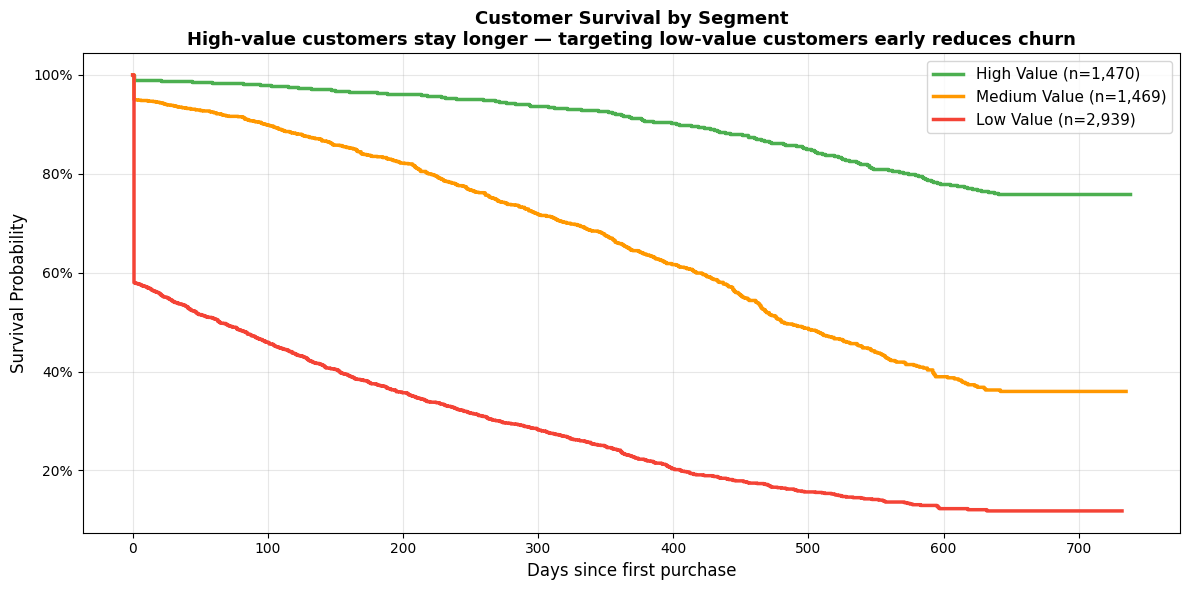


Median survival time by segment:
  High Value      : inf days
  Medium Value    : 480 days
  Low Value       : 64 days


In [0]:
# ============================================================
# Kaplan-Meier by Customer Segment
# High value vs Low value customers — who churns faster?
# ============================================================

# Segment customers by total spend
spend_median = customer_stats['total_spend'].median()
spend_75th   = customer_stats['total_spend'].quantile(0.75)

def segment_customer(spend):
    if spend >= spend_75th:
        return 'High Value'
    elif spend >= spend_median:
        return 'Medium Value'
    else:
        return 'Low Value'

customer_stats['segment'] = customer_stats['total_spend'].apply(segment_customer)

print("Customer segments:")
print(customer_stats['segment'].value_counts().to_string())
print()

# Plot survival curves by segment
fig, ax = plt.subplots(figsize=(12, 6))

colors   = {'High Value': '#4CAF50', 'Medium Value': '#FF9800', 'Low Value': '#F44336'}
segments = ['High Value', 'Medium Value', 'Low Value']

median_times = {}
for segment in segments:
    mask = customer_stats['segment'] == segment
    kmf_seg = KaplanMeierFitter()
    kmf_seg.fit(
        durations      = customer_stats.loc[mask, 'duration'],
        event_observed = customer_stats.loc[mask, 'churned'],
        label          = f'{segment} (n={mask.sum():,})'
    )
    kmf_seg.plot_survival_function(
        ax        = ax,
        ci_show   = False,
        color     = colors[segment],
        linewidth = 2.5
    )
    median_times[segment] = kmf_seg.median_survival_time_

ax.set_title(
    'Customer Survival by Segment\nHigh-value customers stay longer — targeting low-value customers early reduces churn',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Days since first purchase', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%')
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/survival_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMedian survival time by segment:")
for seg, time in median_times.items():
    print(f"  {seg:<15} : {time:.0f} days")

**Cox Proportional Hazards Model**

In [0]:
# ============================================================
# Cox Proportional Hazards Model
# Identifies WHICH factors most influence churn risk
# ============================================================

print("Fitting Cox Proportional Hazards model...")
print("This identifies what drives customer churn...\n")

# Prepare features for Cox model
cox_features = [
    'duration', 'churned',
    'total_orders', 'total_spend',
    'avg_order_value', 'unique_products',
    'purchase_frequency'
]

cox_df = customer_stats[cox_features].copy()

# Normalise continuous features for better model stability
for col in ['total_orders','total_spend','avg_order_value',
            'unique_products','purchase_frequency']:
    cox_df[col] = np.log1p(cox_df[col])

# Remove any infinite or null values
cox_df = cox_df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Customers used in Cox model : {len(cox_df):,}")

# Fit Cox model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    cox_df,
    duration_col = 'duration',
    event_col    = 'churned'
)

print("\n=== Cox Model Summary ===")
cph.print_summary()

Fitting Cox Proportional Hazards model...
This identifies what drives customer churn...

Customers used in Cox model : 5,878

=== Cox Model Summary ===


<lifelines.CoxPHFitter: fitted with 5878 total observations, 2893 right-censored observations>
             duration col = 'duration'
                event col = 'churned'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 5878
number of events observed = 2985
   partial log-likelihood = -21700.51
         time fit was run = 2026-03-22 00:13:32 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
total_orders       -1.01      0.37      0.04           -1.08           -0.94                0.34                0.39
total_spend        -0.21      0.81      0.02           -0.25           -0.17                0.78                0.84
avg_order_value    -0.01      0.99      0.03           -0.06            0.04                0.94                1.04
unique_products    -0.18      0.83      0.02           -0.23           -0.14                0.79                0.87
purchase_frequency  1.13      3.09      0.03            1.07            1.19                2.91                3.28

                    cmp to      z      p  -log2(p)
covariate                                         
total_orders          0.00 -28.32 <0.005    583.66
total_spend           0.00  -9.79 <0.005     72.80
avg_order_value       0.00  -0.33   0.74      0.44
unique_products       0.00  -7.80 <0.005     47.19
purchase_frequency    0.00  36.70 <0.005    977.14
---
Concordance = 0.92
Partial AIC = 43411.01
log-likelihood ratio test = 5297.19 on 5 df
-log2(p) of ll-ratio test = inf

**Cox Model Visualization**

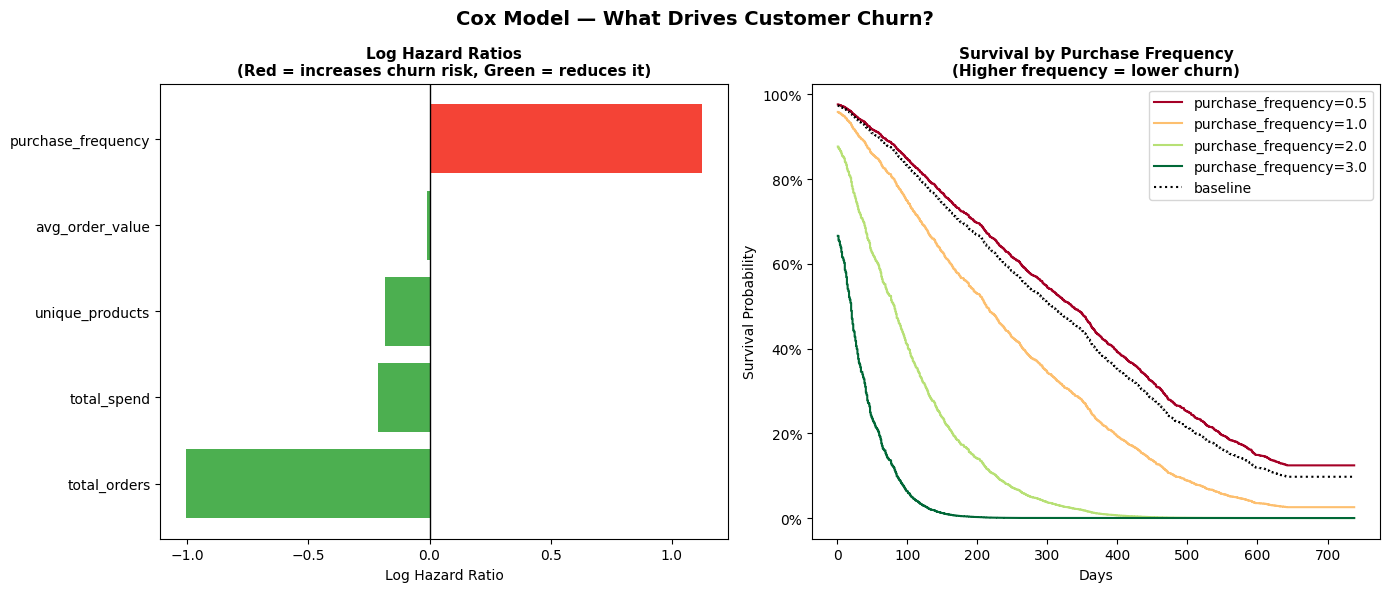


Key findings from Cox model:
  Negative coefficient = REDUCES churn risk (good)
  Positive coefficient = INCREASES churn risk (bad)

  total_orders              : reduces churn risk (coef=-1.006)
  total_spend               : reduces churn risk (coef=-0.211)
  unique_products           : reduces churn risk (coef=-0.184)
  avg_order_value           : reduces churn risk (coef=-0.009)
  purchase_frequency        : increases churn risk (coef=1.127)


In [0]:
# ============================================================
# Visualise Cox Model Results
# Shows which factors increase or decrease churn risk
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Cox Model — What Drives Customer Churn?',
    fontsize=14, fontweight='bold'
)

# Chart 1 — Hazard ratios (which factors affect churn)
coef_df = pd.DataFrame({
    'feature'    : cph.params_.index,
    'coef'       : cph.params_.values,
    'exp_coef'   : np.exp(cph.params_.values)
}).sort_values('coef', ascending=True)

colors_bar = ['#F44336' if c > 0 else '#4CAF50' for c in coef_df['coef']]
axes[0].barh(coef_df['feature'], coef_df['coef'], color=colors_bar)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title(
    'Log Hazard Ratios\n(Red = increases churn risk, Green = reduces it)',
    fontweight='bold', fontsize=11
)
axes[0].set_xlabel('Log Hazard Ratio')

# Chart 2 — Survival prediction by purchase frequency
cph.plot_partial_effects_on_outcome(
    covariates  = 'purchase_frequency',
    values      = [0.5, 1.0, 2.0, 3.0],
    ax          = axes[1],
    cmap        = 'RdYlGn'
)
axes[1].set_title(
    'Survival by Purchase Frequency\n(Higher frequency = lower churn)',
    fontweight='bold', fontsize=11
)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Survival Probability')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%')
)

plt.tight_layout()
plt.savefig('/tmp/cox_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey findings from Cox model:")
print("  Negative coefficient = REDUCES churn risk (good)")
print("  Positive coefficient = INCREASES churn risk (bad)")
print()
for _, row in coef_df.sort_values('coef').iterrows():
    direction = "reduces" if row['coef'] < 0 else "increases"
    print(f"  {row['feature']:<25} : {direction} churn risk (coef={row['coef']:.3f})")

**Identify At-Risk Customers**

In [0]:
# ============================================================
# Identify At-Risk Customers
# These are the customers to target with retention campaigns
# ============================================================

print("Identifying at-risk customers...\n")

# At-risk = active customers likely to churn soon
# Active = not yet churned (days_since_last <= 90)
# At-risk = days_since_last between 60 and 90

active_customers = customer_stats[customer_stats['churned'] == 0].copy()

at_risk = active_customers[
    active_customers['days_since_last'].between(60, 90)
].copy()

at_risk['risk_score'] = (
    at_risk['days_since_last'] / 90 * 0.5 +
    (1 / at_risk['total_orders'].clip(lower=1)) * 0.3 +
    (1 / at_risk['total_spend'].clip(lower=1)) * 0.2
).round(4)

at_risk = at_risk.sort_values('risk_score', ascending=False)

print(f"Total active customers    : {len(active_customers):,}")
print(f"At-risk customers (60-90 days inactive) : {len(at_risk):,}")
print(f"\nTop 10 highest-risk customers to target:")
print(at_risk[['Customer ID','days_since_last','total_orders',
               'total_spend','risk_score']].head(10).to_string())

# Business value of retaining at-risk customers
avg_spend = at_risk['total_spend'].mean()
print(f"\nBusiness case for retention campaign:")
print(f"  At-risk customers          : {len(at_risk):,}")
print(f"  Avg historical spend       : £{avg_spend:,.2f}")
print(f"  Potential revenue at risk  : £{len(at_risk) * avg_spend:,.2f}")
print(f"  If 30% retained (industry avg): £{len(at_risk) * avg_spend * 0.30:,.2f} saved")

Identifying at-risk customers...

Total active customers    : 2,893
At-risk customers (60-90 days inactive) : 497

Top 10 highest-risk customers to target:
      Customer ID  days_since_last  total_orders  total_spend  risk_score
2659        15035               89             1       252.73      0.7952
1016        13372               89             1       378.64      0.7950
4406        16796               88             1       305.62      0.7895
616         12965               88             1       771.91      0.7891
536         12884               87             1       309.05      0.7840
4641        17037               87             1      1267.32      0.7835
408         12756               86             1       112.08      0.7796
4567        16959               86             1       117.35      0.7795
2967        15343               86             1       364.50      0.7783
4487        16878               83             1        13.30      0.7761

Business case for retention c

**Save Results and Log to MLflow**

In [0]:
# ============================================================
# Save survival results to S3 and log to MLflow
# ============================================================

import mlflow

mlflow.set_experiment("/ecom-project/survival-analysis")

with mlflow.start_run(run_name="survival_analysis_v1"):

    # Log parameters
    mlflow.log_param("churn_definition_days",  90)
    mlflow.log_param("model_type",             "kaplan_meier + cox_ph")
    mlflow.log_param("total_customers",        len(customer_stats))
    mlflow.log_param("cox_penalizer",          0.1)

    # Log metrics
    mlflow.log_metric("churn_rate_pct",
                      round(customer_stats['churned'].mean() * 100, 2))
    mlflow.log_metric("median_survival_days",
                      float(kmf.median_survival_time_))
    mlflow.log_metric("survival_at_90_days",
                      round(float(prob_90) * 100, 2))
    mlflow.log_metric("survival_at_180_days",
                      round(float(prob_180) * 100, 2))
    mlflow.log_metric("survival_at_365_days",
                      round(float(prob_365) * 100, 2))
    mlflow.log_metric("at_risk_customers",     len(at_risk))
    mlflow.log_metric("potential_revenue_at_risk",
                      round(len(at_risk) * avg_spend, 2))

    run_id = mlflow.active_run().info.run_id

# Save customer survival data to S3
print("Saving survival results to S3...")
survival_buffer = io.BytesIO()
customer_stats.to_parquet(survival_buffer, index=False)
survival_buffer.seek(0)
s3.put_object(
    Bucket = BUCKET,
    Key    = "outputs/customer_survival_data.parquet",
    Body   = survival_buffer.getvalue()
)
print("Saved : outputs/customer_survival_data.parquet")

# Save at-risk customers to S3
atrisk_buffer = io.BytesIO()
at_risk.to_parquet(atrisk_buffer, index=False)
atrisk_buffer.seek(0)
s3.put_object(
    Bucket = BUCKET,
    Key    = "outputs/at_risk_customers.parquet",
    Body   = atrisk_buffer.getvalue()
)
print("Saved : outputs/at_risk_customers.parquet")

print(f"\nMLflow run ID : {run_id}")
print(f"\n{'='*50}")
print("MODULE 2 — SURVIVAL ANALYSIS COMPLETE!")
print(f"{'='*50}")
print(f"Churn rate           : {customer_stats['churned'].mean()*100:.1f}%")
print(f"Median survival      : {kmf.median_survival_time_:.0f} days")
print(f"At-risk customers    : {len(at_risk):,}")
print(f"Revenue at risk      : £{len(at_risk) * avg_spend:,.2f}")
print(f"\nNext : Module 3 — Sentiment Analysis")
print(f"Notebook : 04_sentiment_analysis/04_sentiment_analysis")

Saving survival results to S3...
Saved : outputs/customer_survival_data.parquet
Saved : outputs/at_risk_customers.parquet

MLflow run ID : 042affde9f644910ad532b0aba55c723

MODULE 2 — SURVIVAL ANALYSIS COMPLETE!
Churn rate           : 50.8%
Median survival      : 425 days
At-risk customers    : 497
Revenue at risk      : £1,023,283.51

Next : Module 3 — Sentiment Analysis
Notebook : 04_sentiment_analysis/04_sentiment_analysis
